<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/content/02-getting-started/jupyter_notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Syntecxhub_JobSalaryPrediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [4]:
import zipfile
import os
import pandas as pd # Ensure pandas is imported if not already in the cell

# Define the path to the zip file and the directory for extraction
zip_path = "/content/archive (1).zip"
extract_dir = "/content/job_salary_data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the contents of the zip file
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Successfully extracted {zip_path} to {extract_dir}")

    # The actual CSV file name found in the extracted directory
    csv_file_name = "job_salary_prediction_dataset.csv"
    csv_file_path = os.path.join(extract_dir, csv_file_name)

    # Read the CSV file
    if os.path.exists(csv_file_path):
        df = pd.read_csv(csv_file_path)
        print(df.head())
    else:
        print(f"Error: '{csv_file_name}' not found inside the extracted directory '{extract_dir}'.")
        print(f"Please check the contents of '{extract_dir}'. Current files: {os.listdir(extract_dir)}")

except FileNotFoundError:
    print(f"Error: Zip file not found at {zip_path}. Please ensure '{zip_path}' exists.")
except Exception as e:
    print(f"An unexpected error occurred during extraction or reading: {e}")

Successfully extracted /content/archive (1).zip to /content/job_salary_data
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


In [5]:
# check structure
print(df.info())

# missing values
print(df.isnull().sum())

# remove duplicates
df = df.drop_duplicates()

# fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("After cleaning shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64
After cleaning shape: (250000, 10)


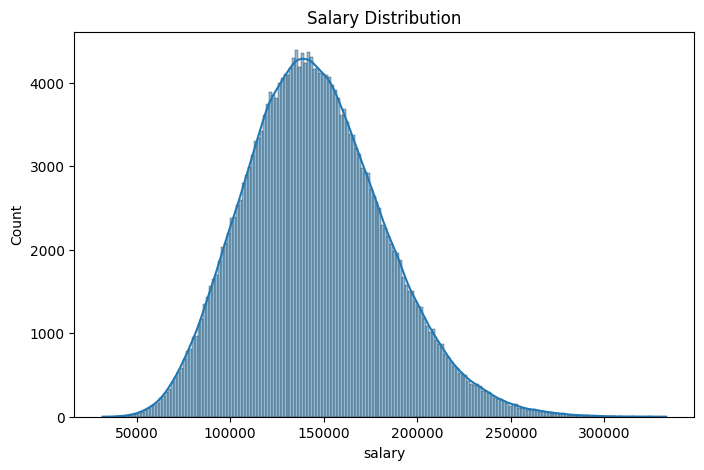

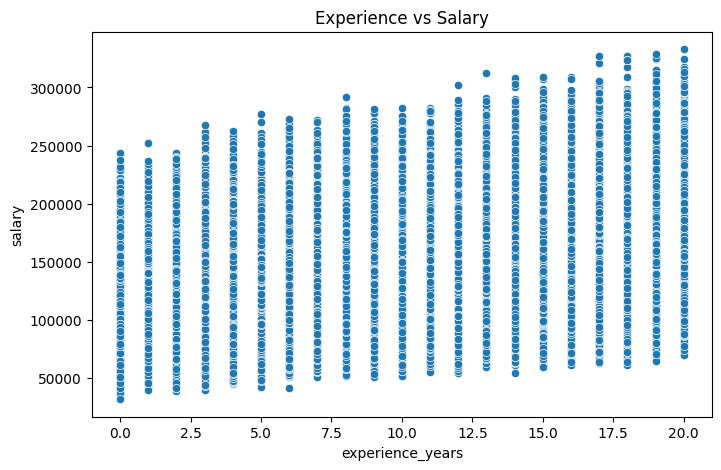

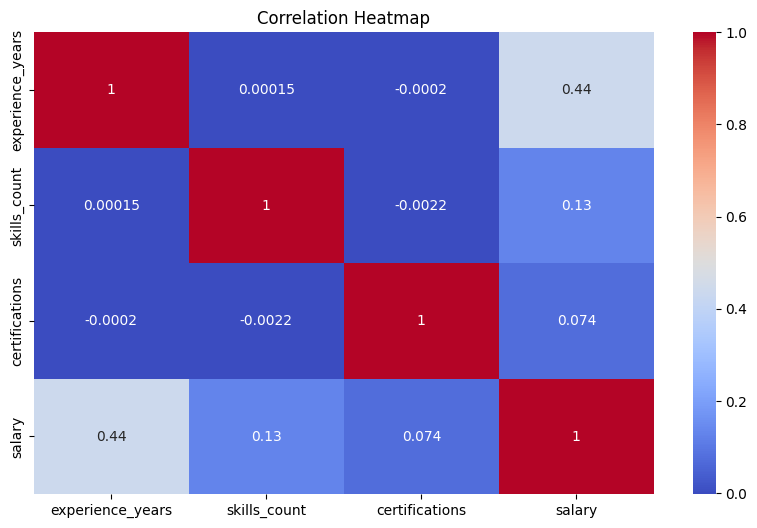

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["experience_years"], y=df["salary"])
plt.title("Experience vs Salary")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
target = "salary"

y = df[target]
X = df.drop(target, axis=1)

# handle categorical features
X = pd.get_dummies(X, drop_first=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



In [12]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

multi_pred = multi_model.predict(X_test)

multi_rmse = np.sqrt(mean_squared_error(y_test, multi_pred))
multi_r2 = r2_score(y_test, multi_pred)

print("MULTIPLE LINEAR REGRESSION")
print("RMSE:", multi_rmse)
print("R2:", multi_r2)

MULTIPLE LINEAR REGRESSION
RMSE: 7125.522904124896
R2: 0.963469022844696


In [13]:
if "Experience" in df.columns:
    X_simple = df[["Experience"]]
else:
    X_simple = df[[X.columns[0]]]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

simple_pred = simple_model.predict(X_test_s)

simple_rmse = np.sqrt(mean_squared_error(y_test_s, simple_pred))
simple_r2 = r2_score(y_test_s, simple_pred)

print("\nSIMPLE LINEAR REGRESSION")
print("RMSE:", simple_rmse)
print("R2:", simple_r2)


SIMPLE LINEAR REGRESSION
RMSE: 33584.33146679785
R2: 0.18847627018893176


In [14]:
if multi_r2 > simple_r2:
    best_model = multi_model
    print("\nBest Model: Multiple Linear Regression")
else:
    best_model = simple_model
    print("\nBest Model: Simple Linear Regression")


Best Model: Multiple Linear Regression


In [15]:
joblib.dump(best_model, "salary_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [16]:
sample = X_test.iloc[0:1]
prediction = best_model.predict(sample)

print("Predicted Salary:", prediction[0])
print("Actual Salary:", y_test.iloc[0])

Predicted Salary: 172850.85075644456
Actual Salary: 164009
